Here w visualize and quantify how a perturbation changes separation within cell subtypes relative to control.

In [1]:
import os
import sys
import warnings
import copy
from contextlib import contextmanager
from collections import defaultdict
import joblib


from tqdm import trange, tqdm

import numpy as np
import pandas as pd
import scanpy as sc

from scipy.spatial.distance import mahalanobis, cosine
from scipy import stats
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
sns.set_context(
    "paper",
    rc={
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "legend.fontsize": 12,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
    }
)

import sys
sys.path.insert(1, '../../.')
from McCauley_utils import all_data

sys.path.insert(1, '../../../.')
from notebook_utils import clear_adata, get_split

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import latent_separation as ls


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install

In [2]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)


In [3]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data


In [5]:
@contextmanager
def suppress_all_output():
    """
    Suppress stdout, stderr, warnings, tqdm, and most parallel chatter.
    """
    # save originals
    old_stdout = sys.stdout
    old_stderr = sys.stderr

    try:
        # redirect stdout / stderr
        sys.stdout = open(os.devnull, 'w')
        sys.stderr = open(os.devnull, 'w')

        # silence warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            # silence tqdm globally
            os.environ["TQDM_DISABLE"] = "1"

            yield

    finally:
        # restore
        sys.stdout.close()
        sys.stderr.close()
        sys.stdout = old_stdout
        sys.stderr = old_stderr

        os.environ.pop("TQDM_DISABLE", None)

# as in Notebook 04
csw = {
    'max_components': 25 ,
    'metric': 'accuracy', 
    'method': 'elbow', 
    'n_folds': 5, 
    'seed': 888
}

assessment_kwargs = {
    'n_perm': 100, 
    'get_q2_pval': True, 
    'get_r2_pval': False, 
    'get_accuracy_pval': False,
    'n_folds': 5, 
    'seed': 888
}
        
def run_pls_(tf_adata_sub, n_components = None):
    with suppress_all_output():
        models, X_pls = ls.pls_da(
            adata = tf_adata_sub, 
            n_components = n_components, 
            assess = True, 
            enc_X = None, enc_Y = None, control_confounders = None, 
            separate_by = 'both', 
            pert_col = pert_col, 
            cat_col = 'secretory_mcc_subsets', 
            component_selection_kwargs = csw, 
            assessment_kwargs = assessment_kwargs, 
            n_cores = n_cores, 
            verbose = False
        )

    pls_model = models['pls_model']
    q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
    assert q2y_pval <= 0.05, 'The fit model is not significant'

    # formatting
    tf_adata_sub.obsm['X_pls'] = X_pls
    X_pls = pd.DataFrame(
        X_pls, index = tf_adata_sub.obs_names, columns = ['PLS{}'.format(i+1) for i in range(X_pls.shape[1])]
    )
    for col in [cat_col, 'secretory_mcc_subsets', pert_col]:
        X_pls[col] = tf_adata_sub.obs[col].copy()
        
    return pls_model, X_pls
        
    
def get_mahanalobis_distance(X):
    subtype_labels = X['secretory_mcc_subsets'].unique()
    g1 = X[X['secretory_mcc_subsets'] == subtype_labels[0]].drop(columns='secretory_mcc_subsets')
    g2 = X[X['secretory_mcc_subsets'] == subtype_labels[1]].drop(columns='secretory_mcc_subsets')

    # means
    m1, m2 = g1.mean().values, g2.mean().values

    # pooled covariance
    S = np.cov(np.vstack([g1.values, g2.values]).T)
    S_inv = np.linalg.inv(S)

    # Mahalanobis distance
    m_distance = mahalanobis(m1, m2, S_inv)
    
    return m_distance

def get_euclidean_distance(X):
    subtype_labels = X['secretory_mcc_subsets'].unique()
    g1 = X[X['secretory_mcc_subsets'] == subtype_labels[0]].drop(columns='secretory_mcc_subsets')
    g2 = X[X['secretory_mcc_subsets'] == subtype_labels[1]].drop(columns='secretory_mcc_subsets')

    # means
    m1, m2 = g1.mean().values, g2.mean().values

    # Euclidean distance
    e_distance = np.linalg.norm(m1 - m2)
    
    return e_distance

def get_pert_vector(X):
    pls_cols = X.columns.drop(pert_col)
    ctrl_centroid = X[X[pert_col] == ctrl_pert][pls_cols].mean().values
    pert_centroid = X[X[pert_col] != ctrl_pert][pls_cols].mean().values
    return pert_centroid - ctrl_centroid

def get_projection(vector_a, vector_control):
    """
    Project vector_a onto vector_control and return the scalar coefficient
    of the projection along with the magnitude of the orthogonal error.

    Parameters
    ----------
    vector_a : array-like
        Input vector to be projected (e.g., perturbation vector).
    vector_control : array-like
        Reference vector onto which vector_a is projected (e.g., control/global direction).
    error_frac : float
        Fraction of the total magnitude of vector_a that lies orthogonal to vector_control,
        defined as ||vector_a - projection|| / ||vector_a||.

        This represents the proportion of vector_a that is not explained by the control
        direction (i.e., the perturbation-specific component). Values range from 0 to 1:
            - 0 indicates full alignment with vector_control (no unique component)
            - 1 indicates complete orthogonality (entirely unique component)

    Notes
    -----
    - The projection is computed as:
          proj = (a · c) / (c · c) * c
    - The residual (error) is:
          error = a - proj
    - This decomposition separates vector_a into:
          (i) component aligned with vector_control (shared/global effect)
          (ii) orthogonal component (specific/unique effect)
    - The normalized error (error_frac) provides a scale-invariant measure of the
      unique component, enabling comparison across vectors of different magnitudes.
      Unnormalized residual: the raw size of that unique part. A subtype that shifts a lot will tend to have a bigger residual just because everything about its response is bigger.
      Normalized residual: the unique part divided by the total shift size. So you're asking "of all the shifting this subtype did, what fraction went in a unique direction?"
      euclidean/mahanalobis distance already accounts for the strong subtype shifts
    """

    a = np.asarray(vector_a)
    c = np.asarray(vector_control)

    coef = np.dot(a, c) / np.dot(c, c)
    
    proj = coef * c
    error = a - proj
    error_mag = np.linalg.norm(error)
    
    # normalize to vector being projected -- what fraction of the shift is unique?
    # Unnormalized residual: the raw size of that unique part. A subtype that shifts a lot will tend to have a bigger residual just because everything about its response is bigger.
    # Normalized residual: the unique part divided by the total shift size. So you're asking "of all the shifting this subtype did, what fraction went in a unique direction?"
    # euclidean/mahanalobis distance already accounts for the strong subtype shifts
    
    error_frac = error_mag / np.linalg.norm(vector_a) 

    return coef, error_frac


In [6]:
has_subtype = ['Club', 'Goblet', 'Multiciliated']

ct_pert_map = {}
for ct in tf_adata.obs[cat_col].cat.categories:
    if ct not in has_subtype:
        continue
    ct_pert_map[ct] = sorted(tf_adata.obs[tf_adata.obs[cat_col] == ct][pert_col].unique())
    ct_pert_map[ct].remove(ctrl_pert)

In [7]:
pls_models, pls_dataframes = {}, {}
distances_df = []#defaultdict(list)

for ct, perts in ct_pert_map.items():
    for pert in tqdm(perts):
        cond = '^'.join([ct, pert])
        
        ct_mask = tf_adata.obs[cat_col] == ct
        pert_mask = tf_adata.obs[pert_col].isin([ctrl_pert, pert])
        
        tf_adata_sub = tf_adata[ct_mask & pert_mask].copy()
        
        ctrl_mask = (tf_adata_sub.obs[pert_col] == ctrl_pert)
        a = tf_adata_sub[ctrl_mask].obs.secretory_mcc_subsets.nunique() == 1
        b = tf_adata_sub[~ctrl_mask].obs.secretory_mcc_subsets.nunique() == 1
        if a or b:
            continue
        assert tf_adata_sub.obs.secretory_mcc_subsets.nunique() == 2, 'Incorrect no. of cell type subsets'
        assert tf_adata_sub.obs[cat_col].nunique() == 1, 'Incorrect no. of cell types'
        tf_adata_sub = clear_adata(tf_adata_sub)
        
        # pls
        pls_model, X_pls = run_pls_(tf_adata_sub, n_components = None if cond != 'Club^IFNA2' else 12)
        pls_models[cond] = pls_model
        pls_dataframes[cond] = X_pls
        
        # DISTANCE METRICS
        ctrl_mask = (X_pls[pert_col] == ctrl_pert)
        X_ctrl = X_pls[ctrl_mask].drop(columns = [cat_col, pert_col]).copy()
        X_pert = X_pls[~ctrl_mask].drop(columns = [cat_col, pert_col]).copy()
        
        e_ctrl_distance = get_euclidean_distance(X = X_ctrl)
        e_pert_distance = get_euclidean_distance(X = X_pert)
        
        m_ctrl_distance = get_mahanalobis_distance(X = X_ctrl)
        m_pert_distance = get_mahanalobis_distance(X = X_pert)
        
        # ANGULAR METRICS
        subtype_labels = X_pls['secretory_mcc_subsets'].unique()
        subtype_labels = sorted(subtype_labels, key=lambda x: 'transition' not in x) # transition is first
        subtype_mask = (X_pls.secretory_mcc_subsets == subtype_labels[0])
        X_transitional_subtype = X_pls[subtype_mask].drop(columns = [cat_col, 'secretory_mcc_subsets']).copy()
        X_mature_subtype = X_pls[~subtype_mask].drop(columns = [cat_col, 'secretory_mcc_subsets']).copy()

        # vectors between perturbation and control for each subtype
        transition_vector = get_pert_vector(X = X_transitional_subtype)
        mature_vector = get_pert_vector(X = X_mature_subtype)
        parent_vector = get_pert_vector(X = X_pls.drop(columns = [cat_col, 'secretory_mcc_subsets']).copy()) # not subtype specific

        subtype_cosine = cosine(transition_vector, mature_vector)
        transition_projection_coef, transition_projection_error = get_projection(transition_vector, parent_vector)
        mature_projection_coef, mature_projection_error = get_projection(mature_vector, parent_vector)

        
        # store
        metrics = {
            'euclidean_control_distance': e_ctrl_distance,
            'euclidean_pert_distance': e_pert_distance,
            'euclidean_distance_ratio': e_pert_distance/e_ctrl_distance, 

            'mahanalobis_control_distance': m_ctrl_distance,
            'mahanalobis_pert_distance': m_pert_distance,
            'mahanalobis_distance_ratio': m_pert_distance/m_ctrl_distance, 
            
            'subtype_cosine_distance': subtype_cosine, 
            
            'transition_projection_coef': transition_projection_coef, 
            'transition_projection_error': transition_projection_error, 
            'mature_projection_coef': mature_projection_coef, 
            'mature_projection_error': mature_projection_error, 
            
            'cell_type': ct, 
            'perturbation': pert, 
            'condition': cond
            
        }
        distances_df.append(metrics)

 20%|█████████████▌                                                      | 1/5 [01:27<05:51, 87.78s/it]/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/sklearn/cross_decomposition/_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)
100%|████████████████████████████████████████████████████████████████████| 4/4 [00:54<00:00, 13.73s/it]


In [8]:
distances_df = pd.DataFrame(distances_df)

In [9]:
distances_df[['condition', 'euclidean_distance_ratio', 'mahanalobis_distance_ratio']]

,condition,euclidean_distance_ratio,mahanalobis_distance_ratio
0,Club^BMP4,0.948567,0.707551
1,Club^IFNA2,1.280132,1.649694
2,Club^IFNG,0.544276,0.774059
3,Club^IL13,0.748164,0.881192
4,Club^TGFB1,0.895331,0.660348
5,Multiciliated^BMP4,0.671326,0.887909
6,Multiciliated^IFNA2,0.753652,1.133323
7,Multiciliated^IL13,0.688780,1.432756
8,Multiciliated^TGFB1,0.826337,1.022543


Given that nearly all distance ratios are < 1, perturbations predominantly induce subtype convergence. In this regime, projection error (the component orthogonal to the shared perturbation direction) primarily reflects residual variation under convergence rather than meaningful subtype-specific divergence. Therefore, we exclude projection error features from the PCA.

Given that there are many distance metrics, let's summarize them with PCA:

In [10]:
pca_cols = [
    'euclidean_distance_ratio',      # keeps euclidean, ratio is most meaningful
    'mahanalobis_distance_ratio',    # keeps mahalanobis, ratio is most meaningful
    'subtype_cosine_distance',       # direction-based, independent
#     'transition_projection_error',   # normalized residual (once you normalize it)
#     'mature_projection_error',       # normalized residual (once you normalize it)
]

# euclidean_control_distance and euclidean_pert_distance — redundant with the ratio, and the ratio normalizes out baseline separation differences across cell types
# Same logic for mahanalobis_control_distance and mahanalobis_pert_distance
# transition_projection_coef and mature_projection_coef — the projection coefficient tells you about 
# over/undershooting the parent, which is a magnitude question already partially captured by the distance ratio. 
# The residual error is the more unique piece of information from the projection decomposition

# many of the PCA columns are not highly correlated, so good to include
print(stats.spearmanr(distances_df.euclidean_pert_distance, distances_df.mahanalobis_pert_distance).statistic)
print(stats.spearmanr(distances_df.euclidean_control_distance, distances_df.mahanalobis_control_distance).statistic)
print(stats.spearmanr(distances_df.euclidean_distance_ratio, distances_df.mahanalobis_distance_ratio).statistic)
print(stats.spearmanr(distances_df.transition_projection_error, distances_df.mature_projection_error).statistic)

-0.15
0.31666666666666665
0.049999999999999996
0.16666666666666669


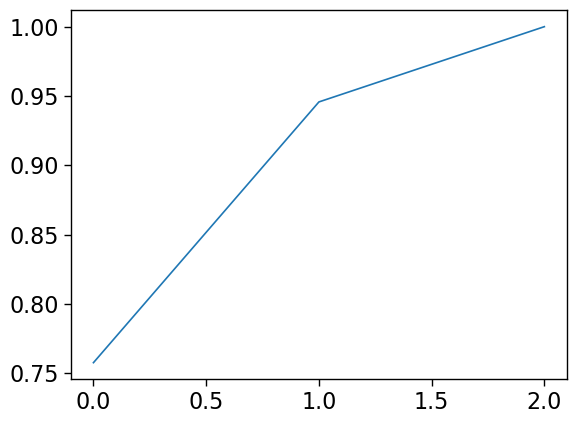

In [11]:
X = distances_df[pca_cols].values

# standardize
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)

# fit PCA
pca_full = PCA()
pca_full.fit(X_scaled)
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))

# 2 components is justified
pca = PCA(n_components=1)   # 2 if including projection errors
X_pca = pca.fit_transform(X_scaled)

# add back to dataframe
distances_df[['PC1']] = X_pca

In [12]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_cols,
    columns=['PC1']#, 'PC2']
)
print(loadings.reindex(loadings['PC1'].abs().sort_values(ascending=False).index)[['PC1']])
# print(loadings.reindex(loadings['PC2'].abs().sort_values(ascending=False).index)[['PC2']])

                                 PC1
subtype_cosine_distance     0.626413
euclidean_distance_ratio    0.579621
mahanalobis_distance_ratio  0.521197


DEPR:

~~PC1 is a general "subtype uniqueness" axis as expected — cosine distance and Euclidean ratio load most strongly, meaning perturbations that score high on PC1 are ones where subtypes move in different directions and converge spatially. Note that mature_projection_error loads negatively while the others are positive — worth checking whether that's a sign convention issue from how you computed the mature vector (recall the copy-paste bug earlier).~~

~~PC2 is more interesting — it separates the projection errors (transition and mature both load positively and strongly) from the Mahalanobis ratio (loads negatively). This axis is essentially asking: "do subtypes have idiosyncratic directional responses, independent of whether they converge in space?" High PC2 = subtypes move in unique directions but don't necessarily converge. Low PC2 = subtypes converge in Mahalanobis space without necessarily having unique directional responses. perturbations that cause large Mahalanobis ratio changes tend to have small projection errors, and vice versa. PC2 is capturing that empirical tradeoff.~~

~~So the 2D space is:~~

~~PC1: overall subtype uniqueness (direction + spatial convergence together)~~
~~PC2: directional uniqueness decoupled from spatial convergence~~

In [13]:
# import matplotlib.pyplot as plt

# fig, ax = plt.subplots(figsize=(6, 6))

# # unique categories
# cell_types = distances_df['cell_type'].unique()
# perts = distances_df['perturbation'].unique()

# # color + marker maps
# colors = plt.cm.tab10(range(len(cell_types)))
# color_map = dict(zip(cell_types, colors))

# markers = ['o', 's', '^', 'D', 'P', 'X', '*']
# marker_map = dict(zip(perts, markers))

# # plot
# for _, row in distances_df.iterrows():
#     ax.scatter(
#         row['PC1'], row['PC2'],
#         color=color_map[row['cell_type']],
#         marker=marker_map[row['perturbation']],
#         s=60
#     )
#     ax.text(row['PC1'], row['PC2'], row['condition'],
#             fontsize=8, ha='center', va='center')

# # axis labels
# ax.set_xlabel('PC1')
# ax.set_ylabel('PC2')
# ax.set_title('PCA of distance metrics')

# # legends
# # cell type legend (colors)
# handles_ct = [
#     plt.Line2D([0], [0], marker='o', color='w',
#                markerfacecolor=color_map[ct], markersize=8, label=ct)
#     for ct in cell_types
# ]

# # perturbation legend (markers)
# handles_pt = [
#     plt.Line2D([0], [0], marker=marker_map[p], color='black',
#                linestyle='None', markersize=8, label=p)
#     for p in perts
# ]

# legend1 = ax.legend(handles=handles_ct, title='Cell Type', loc='upper right')
# ax.add_artist(legend1)
# ax.legend(handles=handles_pt, title='Perturbation', loc='lower right')

# plt.show()

Club and Multiciliated cells separate by PC2, indicating that club tend to have high projection errors and low Mahanalobis distance, and multiciliated do the opposite. 

In [13]:
# var_explained = pca.explained_variance_ratio_  
# distances_df['pc_magnitude_weighted'] = np.sqrt(
#     (distances_df['PC1'] * var_explained[0])**2 + 
#     (distances_df['PC2'] * var_explained[1])**2
# )
# distances_df.sort_values('pc_magnitude_weighted', ascending=False, inplace = True)
distances_df.sort_values('PC1', ascending=False, inplace = True)


In [14]:
distances_df[['condition'] + pca_cols]

,condition,euclidean_distance_ratio,mahanalobis_distance_ratio,subtype_cosine_distance
1,Club^IFNA2,1.280132,1.649694,0.237526
7,Multiciliated^IL13,0.688780,1.432756,0.067594
0,Club^BMP4,0.948567,0.707551,0.082757
8,Multiciliated^TGFB1,0.826337,1.022543,0.039734
3,Club^IL13,0.748164,0.881192,0.074520
6,Multiciliated^IFNA2,0.753652,1.133323,0.025333
4,Club^TGFB1,0.895331,0.660348,0.046812
5,Multiciliated^BMP4,0.671326,0.887909,0.067287
2,Club^IFNG,0.544276,0.774059,0.052298


Condition: Club^BMP4 | 6 components | Q2Y 0.708 (p = 9.90E-03)
Condition: Club^IFNA2 | 12 components | Q2Y 0.710 (p = 9.90E-03)
Condition: Club^IFNG | 8 components | Q2Y 0.403 (p = 9.90E-03)
Condition: Club^IL13 | 5 components | Q2Y 0.606 (p = 9.90E-03)
Condition: Club^TGFB1 | 6 components | Q2Y 0.399 (p = 9.90E-03)
Condition: Multiciliated^BMP4 | 4 components | Q2Y 0.533 (p = 9.90E-03)
Condition: Multiciliated^IFNA2 | 3 components | Q2Y 0.717 (p = 9.90E-03)
Condition: Multiciliated^IL13 | 5 components | Q2Y 0.693 (p = 9.90E-03)
Condition: Multiciliated^TGFB1 | 4 components | Q2Y 0.540 (p = 9.90E-03)


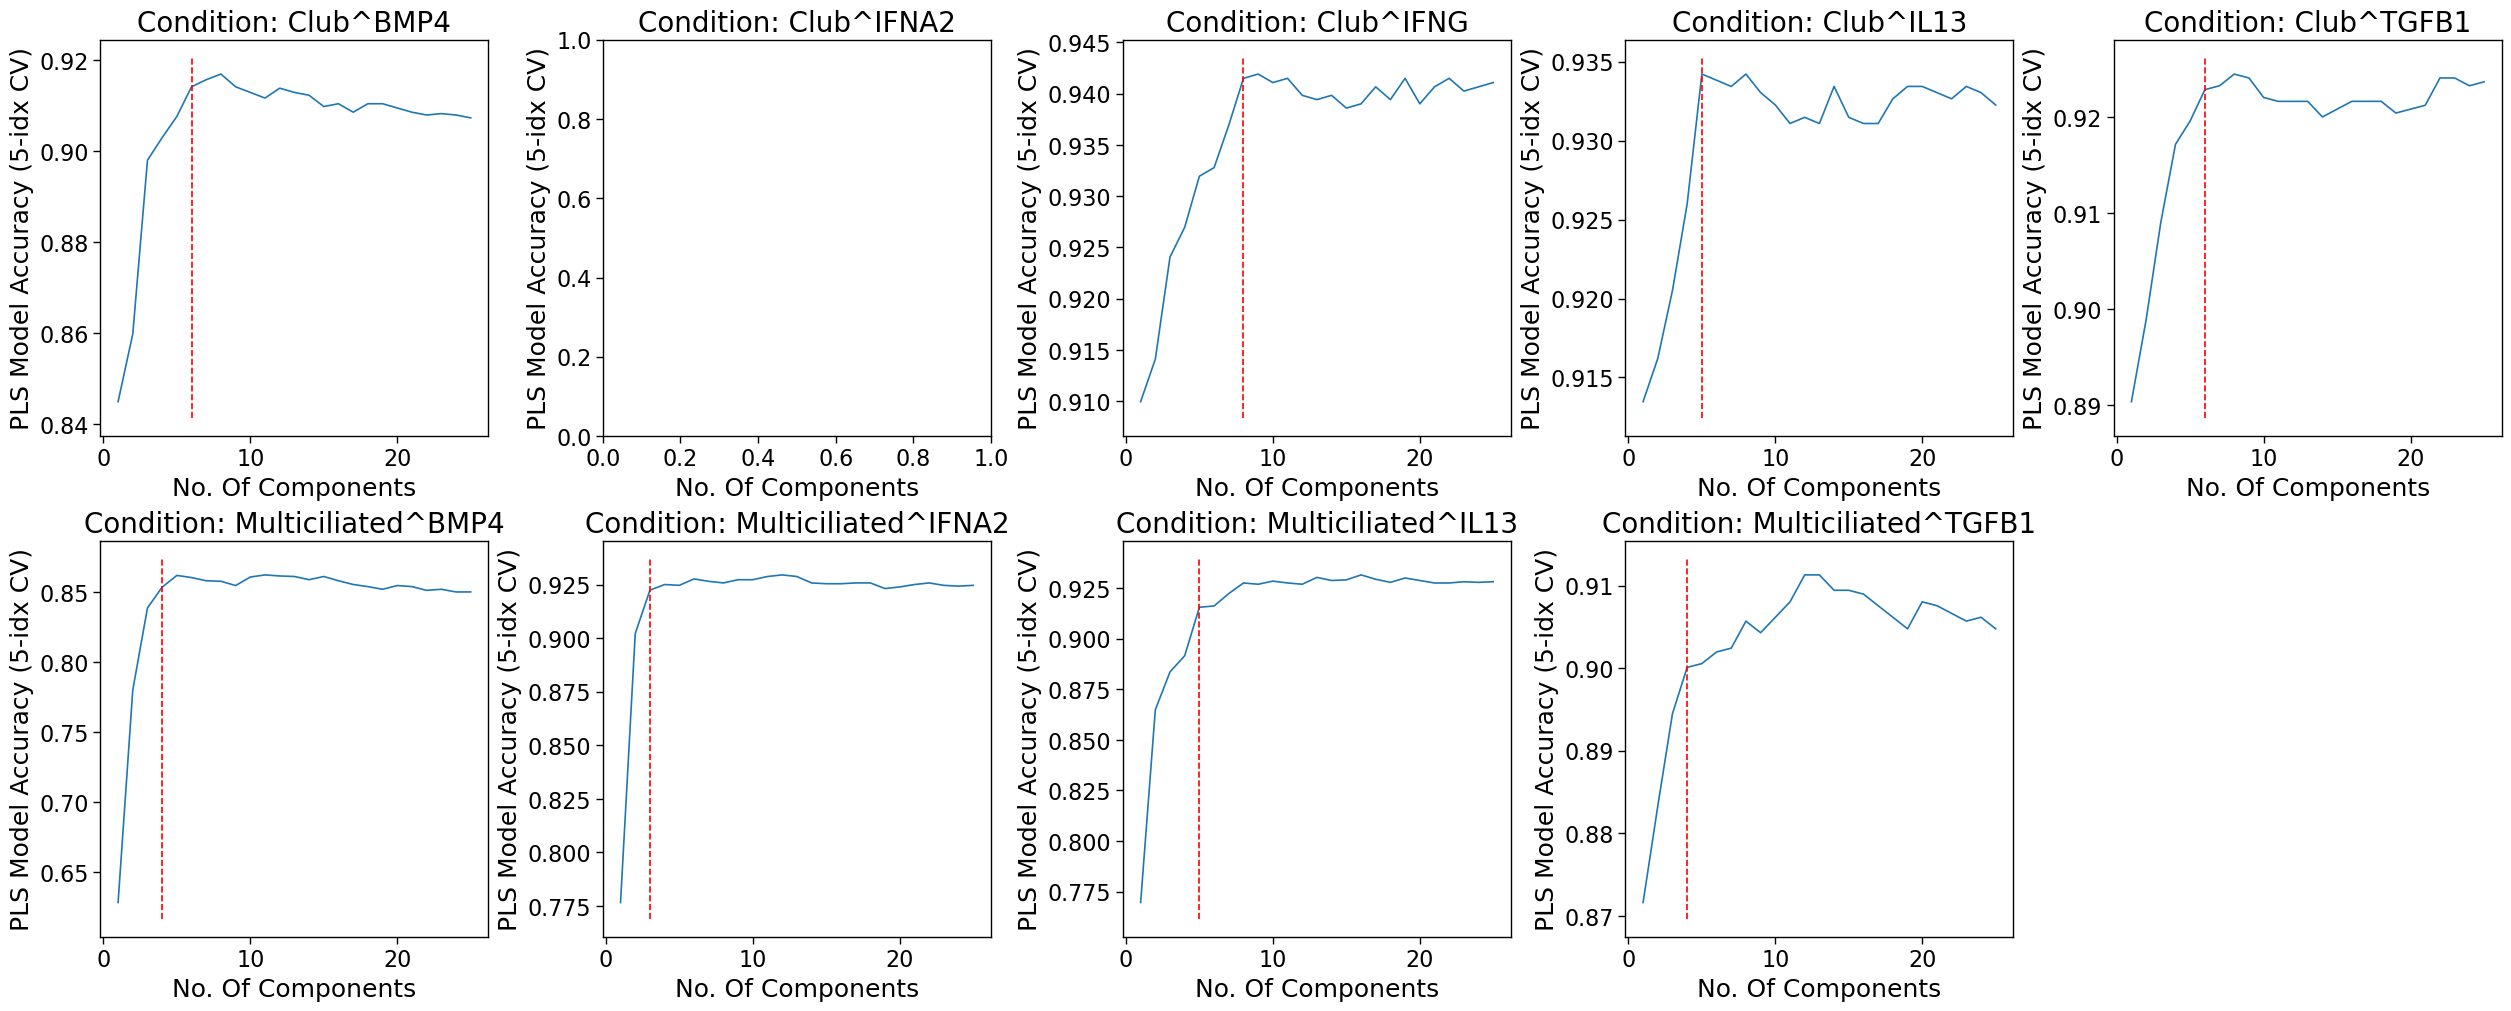

In [16]:
n_panels = len(pls_models) - 1
ncols = min(5, n_panels)
nrows = int(np.ceil(n_panels / ncols))

fig, ax = plt.subplots(nrows = nrows, ncols = ncols, figsize = (5*ncols, 5*nrows), constrained_layout = True)
ax = np.array(ax).reshape(-1)

for idx, (cond, pls_model) in enumerate(pls_models.items()):
    
    ax[idx].set_xlabel('No. Of Components')
    ax[idx].set_ylabel('PLS Model Accuracy (5-idx CV)')
    ax[idx].set_title('Condition: {}'.format(cond))
    
    n_components = pls_model.n_components
    q2y = pls_model.assessment_metrics['Q2Y']['value']
    q2y_pval = pls_model.assessment_metrics['Q2Y']['pval']
    print('Condition: {} | {} components | Q2Y {:.3f} (p = {:.2E})'.format(cond, n_components, q2y, q2y_pval))
    
    if cond == 'Club^IFNA2':
        continue
    
    sns.lineplot(y = pls_model.metric_per_component, x = range(1, len(pls_model.metric_per_component) + 1), ax = ax[idx])
    ymin, ymax = ax[idx].get_ylim()
    ax[idx].vlines(x = pls_model.n_components, ymin = ymin, ymax = ymax, #label = 'Selected No. of Components',
              color = 'red', linestyle = '--'
             )
    
for j in range(idx + 1, len(ax)):
    ax[j].axis('off')
    

Based on the plots above, we will modify the 'Club^IFNA2' condition to contain 12 components rather than 1. 

In [15]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np


def darken_color(color, factor=0.65):
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(np.clip(rgb * factor, 0, 1))


def plot_panel(viz_df, ax, cond_, n_scatter, display_vectors=True):

    pls_cols = [c for c in viz_df.columns if c not in ['secretory_mcc_subsets', pert_col]]
    x_col, y_col = pls_cols[:2]

    viz_df_ = viz_df.copy()

    viz_df_['subtype_plot'] = np.where(
        viz_df_['secretory_mcc_subsets'].str.contains('transitional', case=False, na=False),
        'Transitional',
        'Mature'
    )

    viz_df_['pert_plot'] = np.where(
        viz_df_[pert_col] == ctrl_pert,
        'Control',
        'Perturbed'
    )

    cond_order = [
        'Transitional | Control',
        'Mature | Control',
        'Transitional | Perturbed',
        'Mature | Perturbed'
    ]

    subtype_palette = {
        'Transitional': '#66c2ff',
        'Mature': '#f4a261'
    }

    pert_linestyle = {
        'Control': 'solid',
        'Perturbed': 'dashed'
    }

    pert_marker = {
        'Control': 'o',
        'Perturbed': '^'
    }

    for cond in cond_order:
        subtype, pert_status = cond.split(' | ')
        sub_df = viz_df_[
            (viz_df_['subtype_plot'] == subtype) &
            (viz_df_['pert_plot'] == pert_status)
        ]

        if sub_df.shape[0] > n_scatter:
            sns.kdeplot(
                data=sub_df,
                x=x_col,
                y=y_col,
                ax=ax,
                fill=False,
                levels=5,
                color=subtype_palette[subtype],
                linestyles=pert_linestyle[pert_status]
            )
        else:
            sns.scatterplot(
                data=sub_df,
                x=x_col,
                y=y_col,
                ax=ax,
                color=subtype_palette[subtype],
                marker=pert_marker[pert_status],
                s=40
            )

    if display_vectors:
        for subtype in ['Transitional', 'Mature']:

            control_df = viz_df_[
                (viz_df_['subtype_plot'] == subtype) &
                (viz_df_['pert_plot'] == 'Control')
            ]

            perturbed_df = viz_df_[
                (viz_df_['subtype_plot'] == subtype) &
                (viz_df_['pert_plot'] == 'Perturbed')
            ]

            if control_df.empty or perturbed_df.empty:
                continue

            control_centroid = control_df[[x_col, y_col]].mean().values
            perturbed_centroid = perturbed_df[[x_col, y_col]].mean().values

            arrow_color = darken_color(subtype_palette[subtype], factor=0.65)

            ax.annotate(
                '',
                xy=perturbed_centroid,
                xytext=control_centroid,
                arrowprops=dict(
                    arrowstyle='-|>',
                    color=arrow_color,
                    lw=4.0,
                    mutation_scale=24,
                    shrinkA=0,
                    shrinkB=0
                ),
                zorder=6
            )

    ax.set_title(cond_)

    legend_handles = [
        Patch(facecolor=subtype_palette['Transitional'], label='Transitional'),
        Patch(facecolor=subtype_palette['Mature'], label='Mature'),
        Line2D([0], [0], color='black', lw=2, linestyle='solid', label='Control'),
        Line2D([0], [0], color='black', lw=2, linestyle='dashed', label='Perturbed'),
        Line2D([0], [0], marker='o', linestyle='', color='black', label='Control (scatter)'),
        Line2D([0], [0], marker='^', linestyle='', color='black', label='Perturbed (scatter)')
    ]

    ax.legend(handles=legend_handles, title='Subtype / Perturbation', ncol=3)

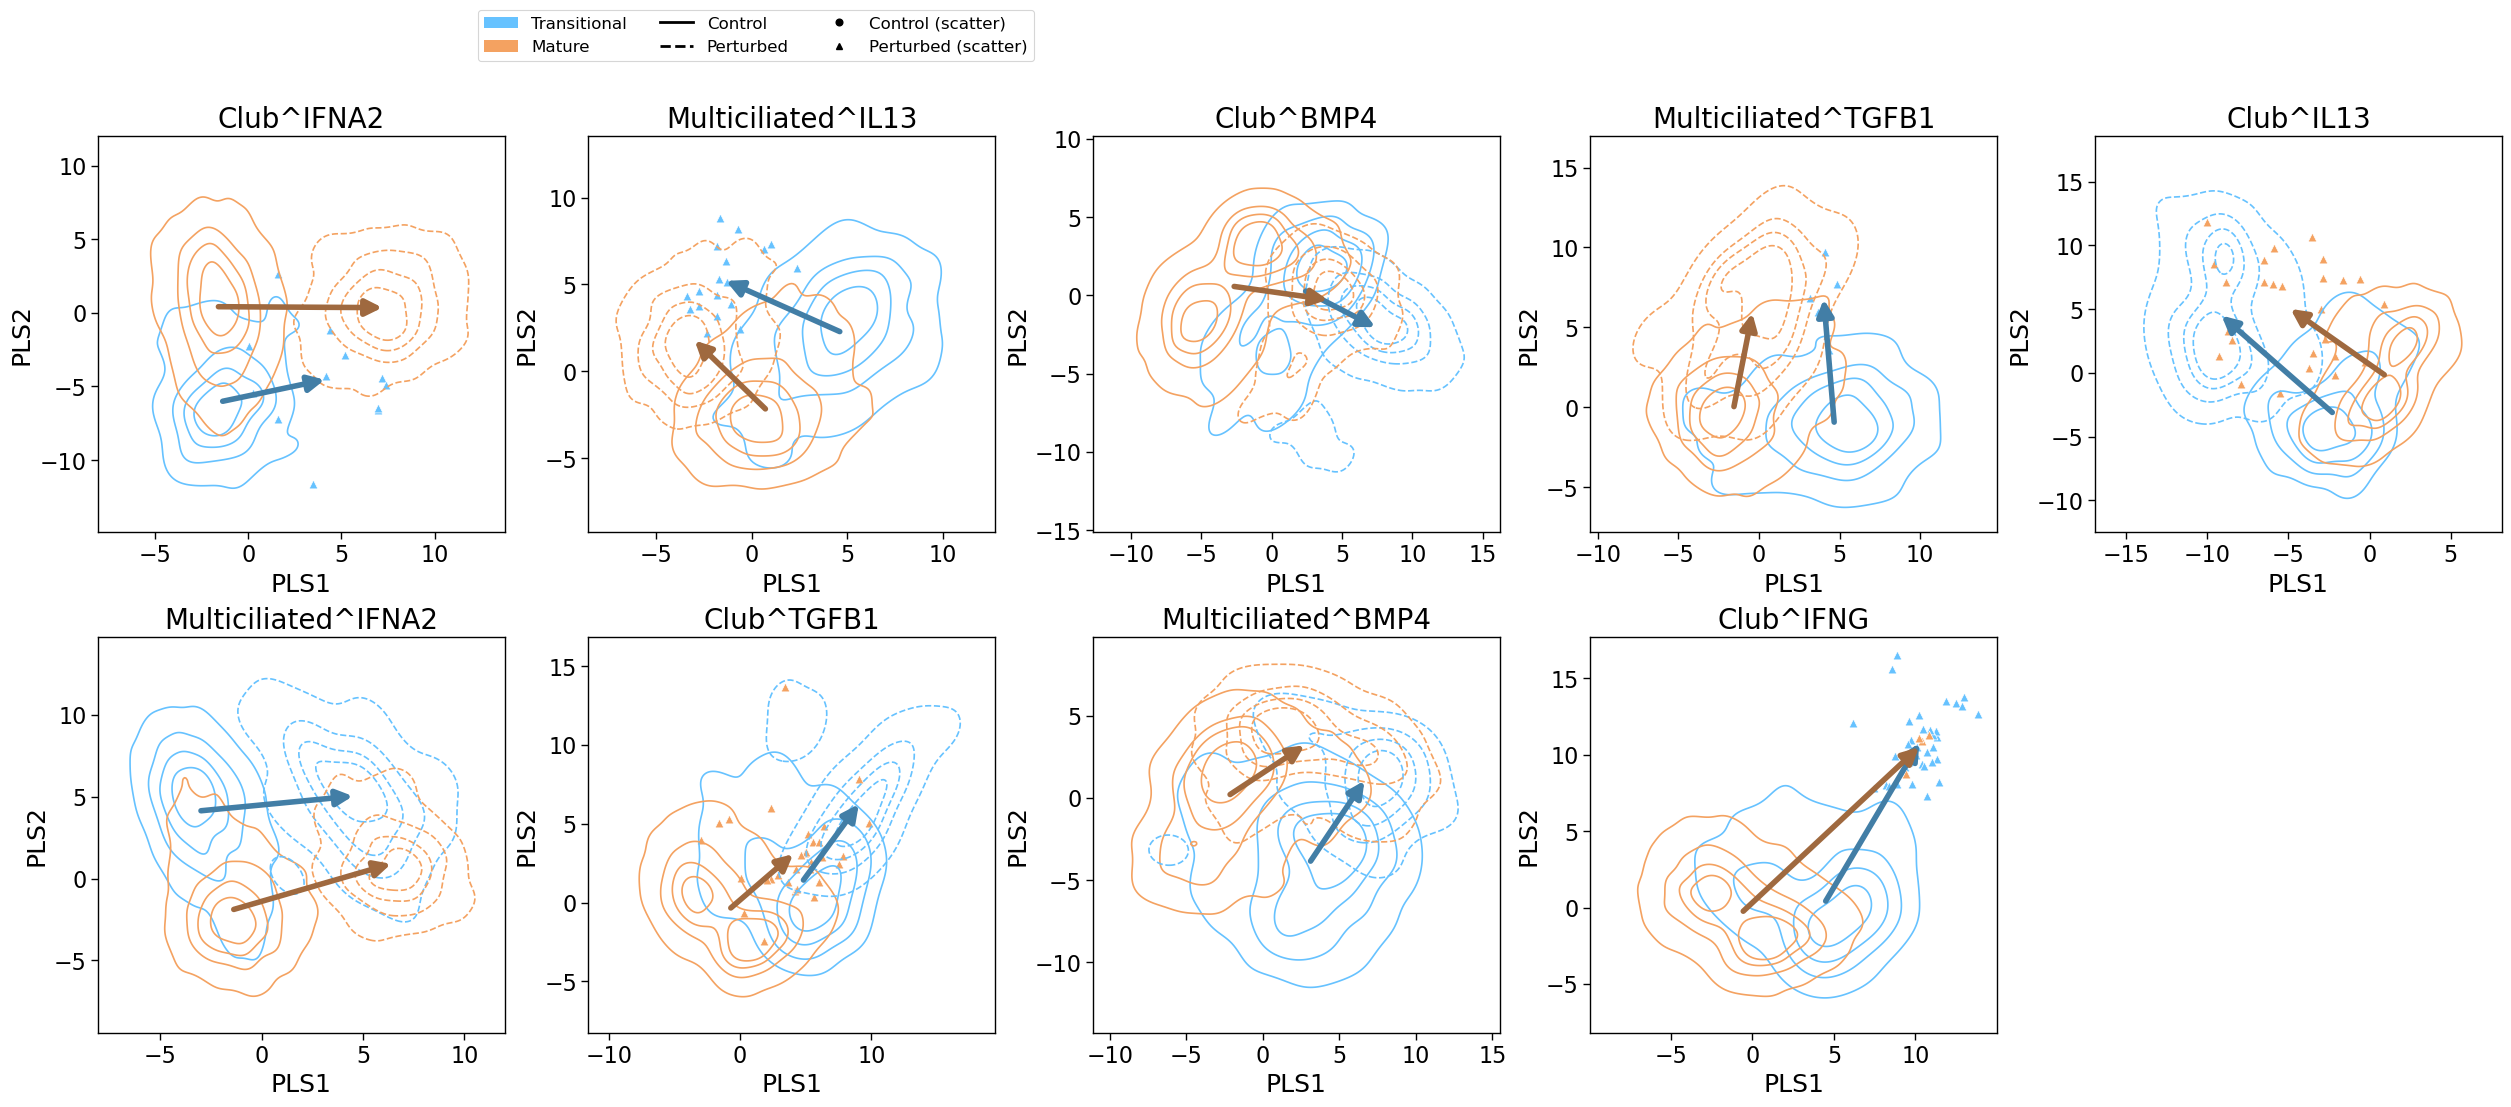

In [16]:
n_panels = distances_df.shape[0]
ncols = min(5, n_panels)
nrows = int(np.ceil(n_panels / ncols))

fig, ax = plt.subplots(nrows = nrows, ncols = ncols, figsize = (5*ncols, 5*nrows), constrained_layout = True)
ax = np.array(ax).reshape(-1)

for idx, cond in enumerate(distances_df.condition):
    viz_df = pls_dataframes[cond].copy().drop(columns = [cat_col])

    plot_panel(viz_df, ax[idx], cond, n_scatter = 50)
    
    if idx == 0:
        legend = ax[idx].get_legend()
        handles = legend.legend_handles
        labels = [t.get_text() for t in legend.texts]
    
    ax[idx].legend_.remove()

# add figure-level legend
fig.legend(
    handles = handles,
    labels = labels,
    loc = 'upper center',
    ncol = 3,
    title = '', 
    bbox_to_anchor = (0.3, 1.1)
)

for j in range(idx + 1, len(ax)):
    ax[j].axis('off')
    

In [135]:
distances_df[['condition'] + pca_cols]

,condition,euclidean_distance_ratio,mahanalobis_distance_ratio,subtype_cosine_distance
1,Club^IFNA2,1.280132,1.649694,0.237526
7,Multiciliated^IL13,0.688780,1.432756,0.067594
0,Club^BMP4,0.948567,0.707551,0.082757
8,Multiciliated^TGFB1,0.826337,1.022543,0.039734
3,Club^IL13,0.748164,0.881192,0.074520
6,Multiciliated^IFNA2,0.753652,1.133323,0.025333
4,Club^TGFB1,0.895331,0.660348,0.046812
5,Multiciliated^BMP4,0.671326,0.887909,0.067287
2,Club^IFNG,0.544276,0.774059,0.052298


It appears perturbations tend to either cause subtype convergence or to cause the same perturbation shift (i.e., start and end points are the same relative to each subtype), rather than divergence. 

The ultimate goal -- to see whether scLEMBAS trained agnostic of subtype labels -- can capture residual varaince of subtypes is most clear in the case of divergence. However, if it does not simply collapse subtypes in instances whereh the perturbation shift is retained, and does converge subtypes in instances when they should converge from distinct starting points, this is still indicative that it captures single-cell resolution. 

In [136]:
joblib.dump(pls_models, os.path.join(data_path, 'processed', 'cellsubtype_pls_models.joblib'))
distances_df.to_csv(os.path.join(data_path, 'interim', 'cellsubtype_pls_euclidean_distances.csv'))

In [4]:
distances_df = pd.read_csv(os.path.join(data_path, 'interim', 'cellsubtype_pls_euclidean_distances.csv'))